In [22]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import  r2_score


In [2]:
df = pd.read_csv(r"C:\Users\sanke\Downloads\Advertising.csv")
df.head(5)

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
#Exploratory Data Analysis
df.isnull().sum()

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

In [4]:
#cheking for duplicates
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop(columns=["Unnamed: 0"])

In [8]:
df.head(5)

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


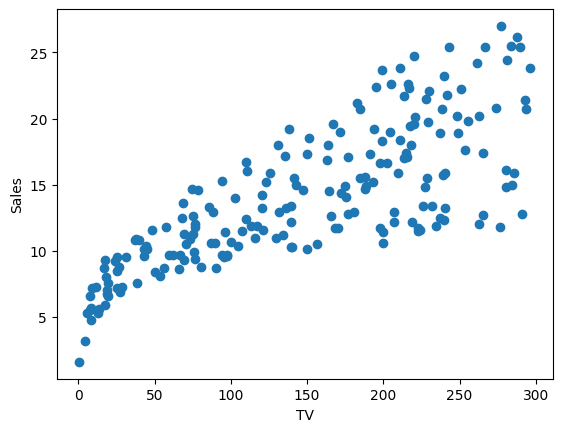

In [ ]:
plt.scatter (df['TV'], df['sales'])
plt.xlabel('TV')
plt.ylabel('Sales')
plt.show()

- As more money is spent on TV ads increases so do sales 

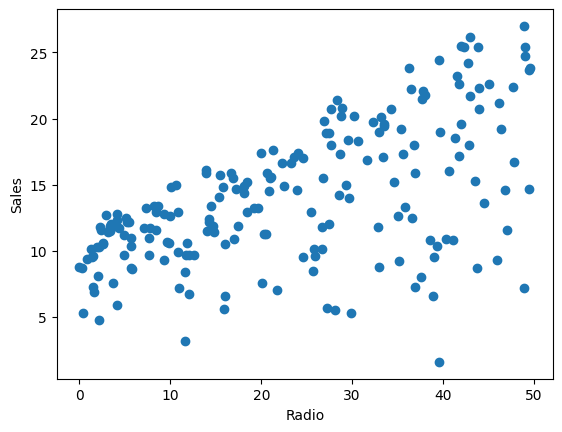

In [ ]:
plt.scatter(df['radio'], df['sales'])
plt.xlabel('Radio')
plt.ylabel('Sales')
plt.show()

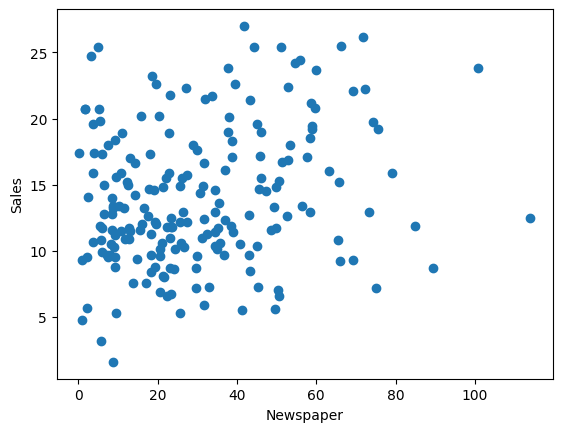

In [ ]:
plt.scatter(df['newspaper'], df['sales'])
plt.xlabel('Newspaper')
plt.ylabel('Sales')
plt.show()

In [35]:
x = df[['TV']]
y = df['sales']

In [36]:
model  = linear_model.LinearRegression()
model.fit(x, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
#training and testing the model to evaluate its accuracy 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
print("Model Coefficient:", model.coef_)


Model Coefficient: [0.04600779]


In [39]:
#predicting
y_pred = model.predict(x_test)

In [40]:
#r2 score
print("R2_score:",r2_score(y_test,y_pred))

R2_score: 0.6763151577939723


- The model predicts only 67% of the sales from money spent on TV adds
- we can improve this by using more independent variables 

In [42]:
#making a prediction for sales 
sales_pred = model.predict([[300]])
print("Predicted sales for TV advertising expenditure of $300:", sales_pred[0])

Predicted sales for TV advertising expenditure of $300: 21.09483065446452


c:\Users\sanke\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'TV Advertising vs Sales with Regression Line')

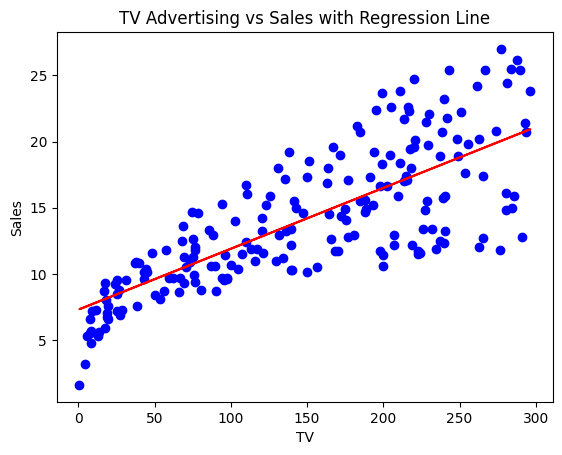

In [51]:
#plotting a regression line
plt.scatter(x, y, color='blue')
plt.plot(x, model.predict(x), color='red')  
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV Advertising vs Sales with Regression Line')

In [44]:
#improving this using multiple linear regression    
X = df[['TV', 'radio', 'newspaper']]
Y = df['sales'] 

In [45]:
mult_model = linear_model.LinearRegression()
mult_model.fit(X, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)
mult_model.fit(X_train, Y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
#evaluating the model
Y_pred = mult_model.predict(X_test)
print("R2_score :" , r2_score(y_pred, Y_test))

R2_score : 0.8330284237692491


- This model now predicts 83.3% of the total sales which is better than 67%

In [54]:
#coefficients
print("Coefficients:", mult_model.coef_)

Coefficients: [ 0.04458402  0.19649703 -0.00278146]


- for a unit increase in the money spent on tv ads the total sales increase by 0.04458402
- for a unit increase in the money spent on radio ads the total sales increase by 0.19649703
- for a unit increase in the money spent on newwspapers the total sales decrease by -0.00278146

In [55]:
pred_sales = mult_model.predict([[300, 50, 20]])
print("Predicted sales for TV advertising expenditure of $300, radio expenditure of $50 and newspaper expenditure of $20:", pred_sales[0])

Predicted sales for TV advertising expenditure of $300, radio expenditure of $50 and newspaper expenditure of $20: 26.139321494616354


c:\Users\sanke\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


ValueError: x and y must be the same size

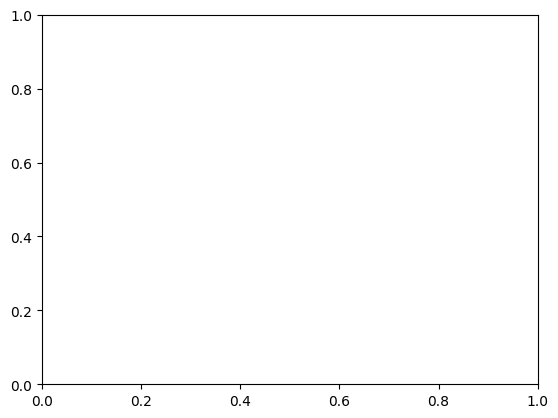

In [56]:
#comparing the actual values of y and the predicted values
plt.scatter(Y,Y_pred)
plt.show()